# 1. Install Dependencies

In [ ]:
# 1. Install precise versions to resolve Tonic's dependency conflicts
!pip install "numpy<2.0.0" --quiet
!pip install expelliarmus --quiet
!pip install spikingjelly --quiet
!pip install tonic --quiet
!pip install h5py importrosbag pbr --quiet

import torch
import torch.nn as nn
import numpy as np
import tonic
import tonic.transforms as tonic_transforms
from torch.utils.data import DataLoader
from spikingjelly.activation_based import neuron, functional, surrogate, layer
import matplotlib.pyplot as plt

# Verify correct device routing
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU Allocated: {torch.cuda.get_device_name(0)}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 103.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tonic 1.6.0 requires expelliarmus, which is not installed.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires n

# 2. Hyperparameters & Config
*Tweak these parameters later to independentally optimize your model's accuracy.*

In [ ]:
BATCH_SIZE = 64
LR = 1e-3
EPOCHS = 10

# SNN Specifics (Exactly matched to your old project run)
TIME_STEPS = 16   # (T) Matching your friend's temporal layout
TAU = 2.0         # Membrane decay time constant (τ)
V_THRESHOLD = 0.5 # Matched to old project threshold configuration!

# 3. Dataset Pipeline (N-MNIST)
*Downloads and prepares the sparse event-camera frames using Tonic.*

In [ ]:
print("Initializing N-MNIST dataset...")

frame_transform = tonic_transforms.ToFrame(
    sensor_size=tonic.datasets.NMNIST.sensor_size,
    n_time_bins=TIME_STEPS,
)

train_raw = tonic.datasets.NMNIST(save_to='./data', train=True, transform=frame_transform)
test_raw  = tonic.datasets.NMNIST(save_to='./data', train=False, transform=frame_transform)

train_dataset = tonic.DiskCachedDataset(train_raw, cache_path="./data/cache_train")
test_dataset  = tonic.DiskCachedDataset(test_raw, cache_path="./data/cache_test")

def collate_fn(batch):
    samples, labels = zip(*batch)
    x = torch.stack([torch.tensor(s, dtype=torch.float32) for s in samples])
    y = torch.tensor(labels, dtype=torch.long)
    return x, y

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, drop_last=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train samples: {len(train_dataset)} | Test samples: {len(test_dataset)}")

Initializing N-MNIST dataset...
Train samples: 60000 | Test samples: 10000


# 4. SNN Model Architecture

In [ ]:
class StandaloneSpikingJellyNet(nn.Module):
    def __init__(self, input_features=2*34*34, hidden_size=50, output_classes=10):
        super().__init__()

        # Mirroring the exact structure: [50, 50, 50, 50, 50, 50, 10]
        self.network = nn.Sequential(
            layer.Flatten(), # Flattens spatial dimensions [T, B, 2, 34, 34] -> [T, B, 2312]

            # Layer 1
            layer.Linear(input_features, hidden_size),
            neuron.LIFNode(tau=TAU, v_threshold=V_THRESHOLD, surrogate_function=surrogate.ATan(), detach_reset=True),

            # Layer 2
            layer.Linear(hidden_size, hidden_size),
            neuron.LIFNode(tau=TAU, v_threshold=V_THRESHOLD, surrogate_function=surrogate.ATan(), detach_reset=True),

            # Layer 3
            layer.Linear(hidden_size, hidden_size),
            neuron.LIFNode(tau=TAU, v_threshold=V_THRESHOLD, surrogate_function=surrogate.ATan(), detach_reset=True),

            # Layer 4
            layer.Linear(hidden_size, hidden_size),
            neuron.LIFNode(tau=TAU, v_threshold=V_THRESHOLD, surrogate_function=surrogate.ATan(), detach_reset=True),

            # Layer 5
            layer.Linear(hidden_size, hidden_size),
            neuron.LIFNode(tau=TAU, v_threshold=V_THRESHOLD, surrogate_function=surrogate.ATan(), detach_reset=True),

            # Layer 6
            layer.Linear(hidden_size, hidden_size),
            neuron.LIFNode(tau=TAU, v_threshold=V_THRESHOLD, surrogate_function=surrogate.ATan(), detach_reset=True),

            # Output Layer (10 classes)
            layer.Linear(hidden_size, output_classes),
            neuron.LIFNode(tau=TAU, v_threshold=V_THRESHOLD, surrogate_function=surrogate.ATan(), detach_reset=True)
        )

    def forward(self, x):
        # Tonic Loader outputs: [Batch, Time, Channels, Height, Width]
        # SpikingJelly step execution expects: [Time, Batch, Channels, Height, Width]
        x = x.permute(1, 0, 2, 3, 4)

        # Pass temporal sequence through the dense network layer chain
        out_spikes = self.network(x)

        # Return the mean spike firing rate over time -> Shape: [Batch, 10]
        return out_spikes.mean(dim=0)

# Initialize model
model = StandaloneSpikingJellyNet()

# Ensure entire sequential network works in sequence step processing mode
functional.set_step_mode(model, step_mode='m')

# Ship to the designated GPU space
model = model.to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# 5. Training and Evaluation Loop

In [ ]:
print("Starting Isolated SNN Optimization...\n")
train_accs, test_accs = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for batch_idx, (images, labels) in enumerate(train_loader):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        functional.reset_net(model) # Essential SpikingJelly cleanup step

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100. * correct / total
    train_accs.append(train_acc)

    model.eval()
    test_correct, test_total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            functional.reset_net(model)
            outputs = model(images)
            _, predicted = outputs.max(1)
            test_total += labels.size(0)
            test_correct += predicted.eq(labels).sum().item()

    test_acc = 100. * test_correct / test_total
    test_accs.append(test_acc)
    print(f"Epoch [{epoch}/{EPOCHS}] | Loss: {total_loss/len(train_loader):.4f} | Train Acc: {train_acc:.2f}% | Test Acc: {test_acc:.2f}%")

Starting Isolated SNN Optimization...

Epoch [1/10] | Loss: 2.0150 | Train Acc: 24.42% | Test Acc: 37.44%
Epoch [2/10] | Loss: 1.7795 | Train Acc: 42.09% | Test Acc: 45.28%
Epoch [3/10] | Loss: 1.7433 | Train Acc: 44.50% | Test Acc: 45.55%
Epoch [4/10] | Loss: 1.7265 | Train Acc: 46.50% | Test Acc: 49.38%
Epoch [5/10] | Loss: 1.6980 | Train Acc: 54.71% | Test Acc: 56.04%
Epoch [6/10] | Loss: 1.6773 | Train Acc: 59.55% | Test Acc: 60.96%
Epoch [7/10] | Loss: 1.6580 | Train Acc: 66.02% | Test Acc: 69.02%
Epoch [8/10] | Loss: 1.6318 | Train Acc: 70.61% | Test Acc: 71.58%
Epoch [9/10] | Loss: 1.6153 | Train Acc: 72.48% | Test Acc: 72.84%
Epoch [10/10] | Loss: 1.6098 | Train Acc: 73.91% | Test Acc: 73.24%


# 6. Plot Results

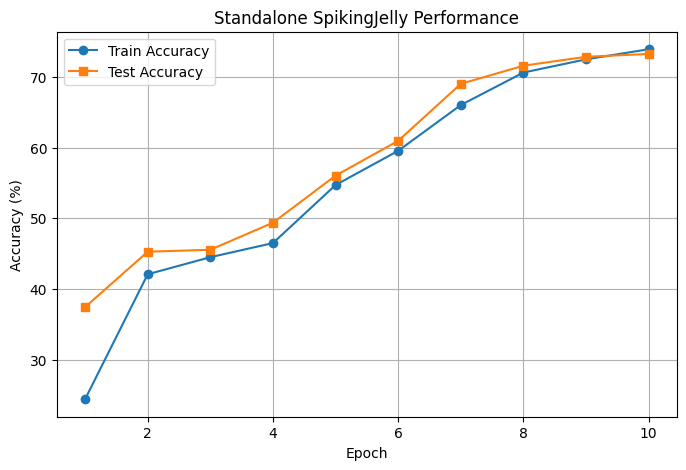

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), train_accs, label="Train Accuracy", marker='o')
plt.plot(range(1, EPOCHS + 1), test_accs, label="Test Accuracy", marker='s')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Standalone SpikingJelly Performance")
plt.legend()
plt.grid(True)
plt.show()